In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mat4py import loadmat

Matplotlib is building the font cache; this may take a moment.


In [5]:
import scipy.io


In [6]:
data = scipy.io.loadmat('../data/raw/B0005.mat')
print(type(data))
print(data.keys())


<class 'dict'>
dict_keys(['__header__', '__version__', '__globals__', 'B0005'])


In [7]:
battery = data['B0005']
print(type(battery))
print(battery.dtype)

<class 'numpy.ndarray'>
[('cycle', 'O')]


In [8]:
cycles = battery['cycle'][0][0]
print(type(cycles))
print(cycles.shape)

<class 'numpy.ndarray'>
(1, 616)


In [9]:
first_cycle = cycles[0][0]
print(first_cycle.dtype)

[('type', 'O'), ('ambient_temperature', 'O'), ('time', 'O'), ('data', 'O')]


In [10]:
print(first_cycle['type'][0])
print(first_cycle['ambient_temperature'][0])
print(first_cycle['data'][0].dtype)

charge
[24]
[('Voltage_measured', 'O'), ('Current_measured', 'O'), ('Temperature_measured', 'O'), ('Current_charge', 'O'), ('Voltage_charge', 'O'), ('Time', 'O')]


In [11]:
discharge_cycles = []
for i in range(cycles.shape[1]):
    cycle = cycles[0][i]
    if cycle['type'][0] == 'discharge':
        discharge_cycles.append(i)

print(f"Total cycles: {cycles.shape[1]}")
print(f"Discharge cycles: {len(discharge_cycles)}")
print(f"First discharge at cycle index: {discharge_cycles[0]}")

Total cycles: 616
Discharge cycles: 168
First discharge at cycle index: 1


In [13]:
capacities = []

for i in discharge_cycles:
    cycle = cycles[0][i]
    current = cycle['data'][0]['Current_measured'][0][0]
    time = cycle['data'][0]['Time'][0][0]
    
    # capacity = integrate current over time (Ah)
    capacity = np.trapezoid(abs(current), time) / 3600
    capacities.append(capacity)

print(f"Initial capacity: {capacities[0]:.4f} Ah")
print(f"Final capacity: {capacities[-1]:.4f} Ah")

Initial capacity: 1.8622 Ah
Final capacity: 1.3280 Ah


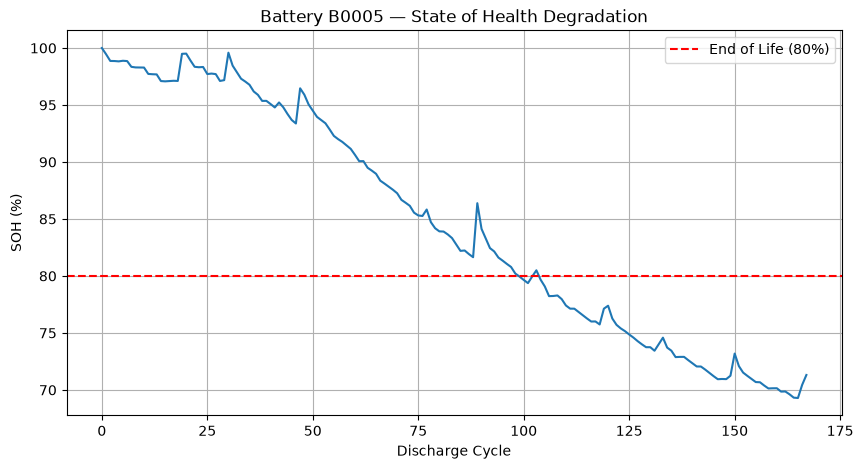

SOH at end: 71.31%


In [14]:
# SOH = current capacity / initial capacity * 100
initial_capacity = capacities[0]
soh = [cap / initial_capacity * 100 for cap in capacities]

# plot
plt.figure(figsize=(10, 5))
plt.plot(soh)
plt.axhline(y=80, color='red', linestyle='--', label='End of Life (80%)')
plt.xlabel('Discharge Cycle')
plt.ylabel('SOH (%)')
plt.title('Battery B0005 — State of Health Degradation')
plt.legend()
plt.grid(True)
plt.show()

print(f"SOH at end: {soh[-1]:.2f}%")